# Irrigation Water-Volume Prediction — Google Colab

This proof-of-concept predicts the **water volume applied per irrigation event (liters)** from the strawberry-field moisture, valve, and flow-meter records.

Models:

1. Random Forest Regressor
2. Ridge Regression

> Important: the target is historically applied water, not a universally optimal crop-water requirement. Only one field and a small number of usable events are available, so results must be treated as preliminary.

In [ ]:
# Google Colab already includes the required libraries.

In [ ]:
# Header: Import libraries and configure analysis and modeling tools
import io
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import files

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Upload the three files

Select `D_valve.txt`, `D_moisture.txt`, and `D_flowmeter.txt` together.

In [ ]:
# Header: Load irrigation data and prepare for analysis
uploaded = files.upload()
required = {'D_valve.txt', 'D_moisture.txt', 'D_flowmeter.txt'}
missing = required.difference(uploaded)
if missing:
    raise ValueError(f'Missing required files: {sorted(missing)}')

valve = pd.read_csv(io.BytesIO(uploaded['D_valve.txt']))
moisture = pd.read_csv(io.BytesIO(uploaded['D_moisture.txt']))
flow = pd.read_csv(io.BytesIO(uploaded['D_flowmeter.txt']))

for frame in (valve, moisture, flow):
    frame['time_stamp'] = pd.to_datetime(
        frame['time_stamp'], format='%d-%b-%Y %H:%M:%S'
    )
    frame.sort_values('time_stamp', inplace=True)

print('Valve:', valve.shape, valve.time_stamp.min(), 'to', valve.time_stamp.max())
print('Moisture:', moisture.shape, moisture.time_stamp.min(), 'to', moisture.time_stamp.max())
print('Flow:', flow.shape, flow.time_stamp.min(), 'to', flow.time_stamp.max())

Saving D_valve.txt to D_valve.txt
Saving D_moisture.txt to D_moisture.txt
Saving D_flowmeter.txt to D_flowmeter.txt
Valve: (17427, 2) 2022-07-12 00:00:00 to 2022-09-16 23:57:37
Moisture: (4293, 2) 2022-07-12 00:03:51 to 2022-09-16 23:56:08
Flow: (17411, 2) 2022-07-12 00:00:15 to 2022-09-16 23:55:16


## 2. Inspect the raw measurements

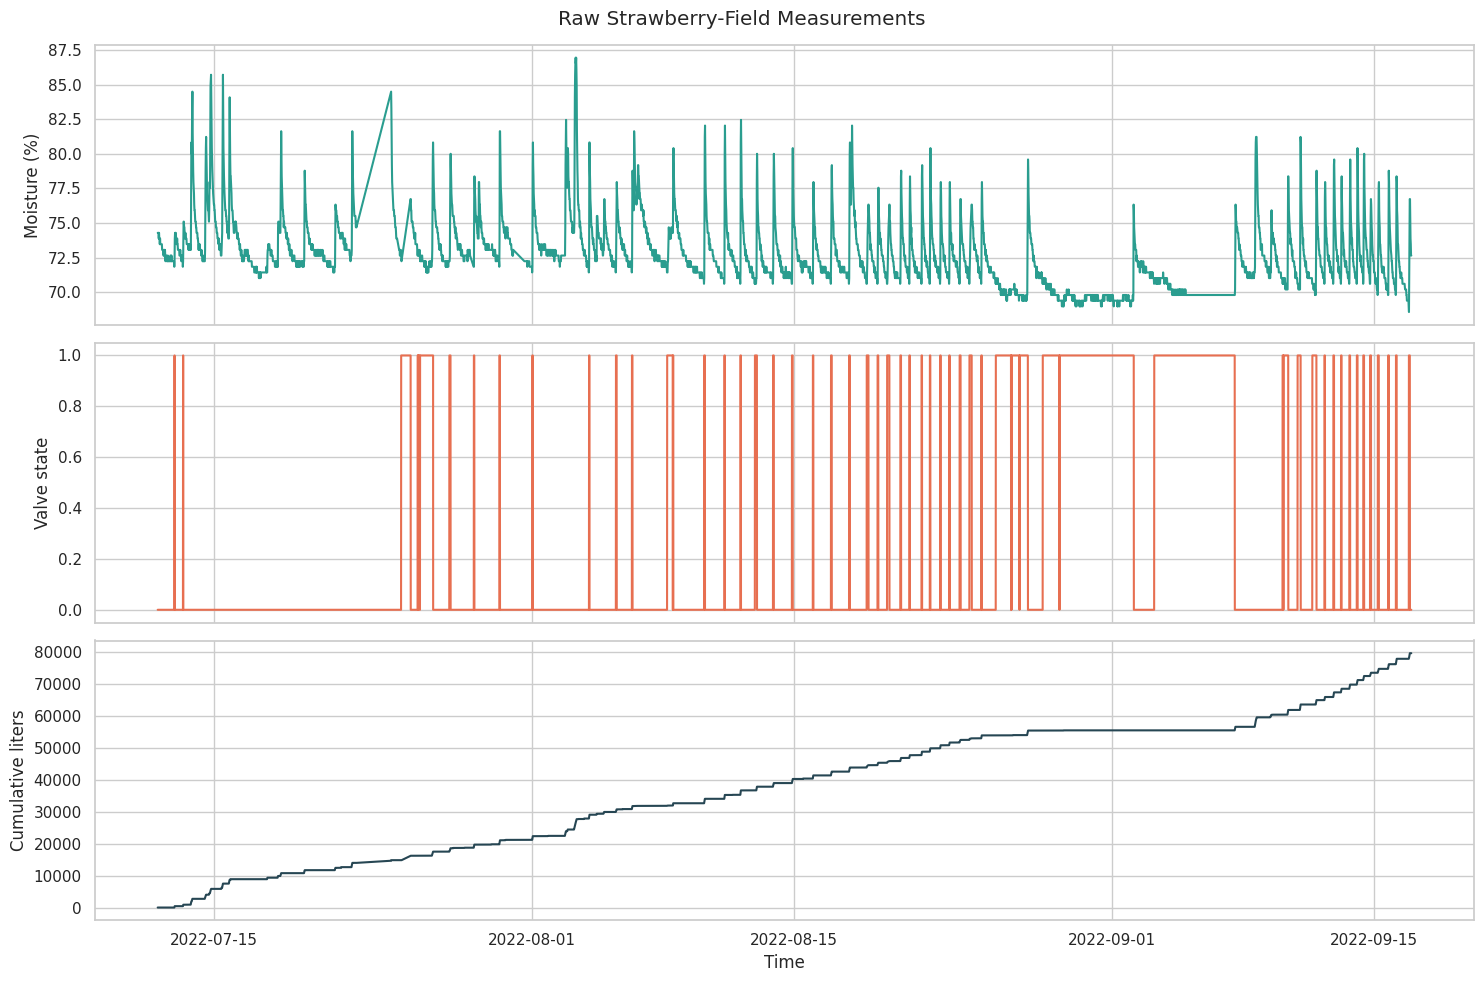

In [ ]:
# Header: Visualize results and compare actual vs predicted values
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
axes[0].plot(moisture.time_stamp, moisture.moisture, color='#2a9d8f')
axes[0].set_ylabel('Moisture (%)')
axes[1].plot(valve.time_stamp, valve.relay, color='#e76f51')
axes[1].set_ylabel('Valve state')
axes[2].plot(flow.time_stamp, flow.litres, color='#264653')
axes[2].set_ylabel('Cumulative liters')
axes[2].set_xlabel('Time')
plt.suptitle('Raw Strawberry-Field Measurements')
plt.tight_layout()
plt.show()

## 3. Convert the time series into irrigation events

A new event begins when the relay changes from closed (`0`) to open (`1`). Event water volume equals the difference between cumulative flow-meter readings at event start and end. Events with zero volume or valve-open duration over six hours are excluded as probable incomplete or abnormal records.

In [ ]:
# Header: Clean data and convert datetime and numeric fields
# Identify consecutive valve-open periods.
valve['event_start'] = valve['relay'].eq(1) & valve['relay'].shift(fill_value=0).eq(0)
valve['event_id'] = valve['event_start'].cumsum()

events = (
    valve[valve['relay'].eq(1)]
    .groupby('event_id')
    .agg(start_time=('time_stamp', 'min'), last_open_time=('time_stamp', 'max'))
    .reset_index()
)
events['end_time'] = events['last_open_time'] + pd.Timedelta(minutes=5)
events['duration_min'] = (events['end_time'] - events['start_time']).dt.total_seconds() / 60

# The flow series contains one duplicate timestamp; retain its latest record.
flow = flow.drop_duplicates('time_stamp', keep='last').sort_values('time_stamp')

def attach_previous_value(left, left_time, right, value, output, tolerance='10min'):
    original = left.reset_index().rename(columns={'index': '_original_index'})
    matched = pd.merge_asof(
        original.sort_values(left_time),
        right[['time_stamp', value]].sort_values('time_stamp'),
        left_on=left_time, right_on='time_stamp', direction='backward',
        tolerance=pd.Timedelta(tolerance)
    ).sort_values('_original_index')
    left[output] = matched[value].to_numpy()

attach_previous_value(events, 'start_time', flow, 'litres', 'start_litres')
attach_previous_value(events, 'end_time', flow, 'litres', 'end_litres')
events['water_amount_liters'] = events['end_litres'] - events['start_litres']

raw_event_count = len(events)
events = events.loc[
    events['water_amount_liters'].gt(0)
    & events['duration_min'].between(5, 360)
].copy().sort_values('start_time').reset_index(drop=True)

print('Detected valve-open events:', raw_event_count)
print('Usable irrigation events:', len(events))
display(events[['start_time', 'end_time', 'duration_min', 'water_amount_liters']].head())

Detected valve-open events: 59
Usable irrigation events: 47


,start_time,end_time,duration_min,water_amount_liters
0,2022-07-12 21:29:31,2022-07-12 21:49:31,20.0,425.300000
1,2022-07-13 08:29:30,2022-07-13 08:49:30,20.0,446.633333
2,2022-07-25 21:29:38,2022-07-25 21:54:38,25.0,25.000000
3,2022-07-25 21:59:38,2022-07-25 22:09:38,10.0,0.033333
4,2022-07-25 22:29:38,2022-07-26 00:09:38,100.0,0.033333


## 4. Create predictors known at the start of each event

Event duration is deliberately excluded: it is only known after irrigation finishes and would leak the answer. Moisture and historical features use information available at or before the event start.

In [ ]:
# Header: Load irrigation data and prepare for analysis
# Moisture at event start.
attach_previous_value(events, 'start_time', moisture, 'moisture', 'start_moisture', tolerance='30min')

# Moisture approximately one hour before the event for a recent trend.
events['one_hour_before'] = events['start_time'] - pd.Timedelta(hours=1)
attach_previous_value(events, 'one_hour_before', moisture, 'moisture', 'moisture_1h_before', tolerance='30min')
events['moisture_change_1h'] = events['start_moisture'] - events['moisture_1h_before']

# Only past-event information is used for lagged irrigation features.
events['hours_since_previous_irrigation'] = (
    events['start_time'] - events['end_time'].shift(1)
).dt.total_seconds() / 3600
events['previous_water_liters'] = events['water_amount_liters'].shift(1)

# Cyclical time features.
events['hour_sin'] = np.sin(2 * np.pi * events['start_time'].dt.hour / 24)
events['hour_cos'] = np.cos(2 * np.pi * events['start_time'].dt.hour / 24)
events['day_index'] = (events['start_time'] - events['start_time'].min()).dt.total_seconds() / 86400

FEATURES = [
    'start_moisture', 'moisture_change_1h',
    'hours_since_previous_irrigation', 'previous_water_liters',
    'hour_sin', 'hour_cos', 'day_index'
]
TARGET = 'water_amount_liters'
model_data = events.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

print('Model-ready events:', len(model_data))
display(model_data[FEATURES + [TARGET]].describe().T)

Model-ready events: 45


,count,mean,std,min,25%,50%,75%,max
start_moisture,45.0,70.910444,0.914574,68.980000,70.610000,70.610000,70.610000,74.290000
moisture_change_1h,45.0,-0.445556,0.243493,-0.820000,-0.410000,-0.410000,-0.410000,0.400000
hours_since_previous_irrigation,45.0,33.328975,71.846297,0.083333,10.666389,13.999722,23.249444,404.985833
previous_water_liters,45.0,968.884444,388.113211,0.033333,804.533333,1025.866667,1206.066667,1705.933333
hour_sin,45.0,-0.034718,0.740528,-1.000000,-0.707107,0.000000,0.866025,1.000000
hour_cos,45.0,0.225218,0.649028,-1.000000,-0.500000,0.500000,0.707107,1.000000
day_index,45.0,39.513551,17.817693,0.458322,28.309826,38.086366,60.811319,65.970903
water_amount_liters,45.0,999.061481,392.672277,0.033333,835.100000,1033.533333,1272.600000,1705.933333


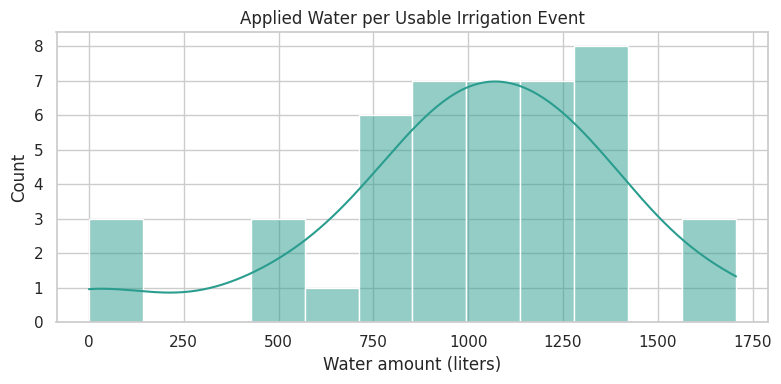

In [ ]:
# Header: Visualize results and compare actual vs predicted values
plt.figure(figsize=(8, 4))
sns.histplot(model_data[TARGET], bins=12, kde=True, color='#2a9d8f')
plt.title('Applied Water per Usable Irrigation Event')
plt.xlabel('Water amount (liters)')
plt.tight_layout()
plt.show()

## 5. Chronological train/test split

The earliest 80% of events are used for training and the latest 20% for testing. A random split is avoided because adjacent time-series observations can otherwise leak temporal patterns.

In [ ]:
# Header: Create temporal features, soil moisture, and previous irrigation features
split_index = int(len(model_data) * 0.80)
train = model_data.iloc[:split_index].copy()
test = model_data.iloc[split_index:].copy()

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print('Training events:', len(train), train.start_time.min(), 'to', train.start_time.max())
print('Testing events:', len(test), test.start_time.min(), 'to', test.start_time.max())

Training events: 36 2022-07-13 08:29:30 to 2022-09-12 19:57:46
Testing events: 9 2022-09-13 05:47:45 to 2022-09-16 20:47:37


## 6. Train exactly two regression models

In [ ]:
# Header: Split data into train/test sets and prepare inputs
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Ridge Regression': make_pipeline(StandardScaler(), Ridge(alpha=10.0))
}

fitted_models, predictions, results = {}, {}, []
baseline_prediction = np.repeat(y_train.median(), len(y_test))
results.append({
    'Model': 'Training Median Baseline',
    'MAE_L': mean_absolute_error(y_test, baseline_prediction),
    'RMSE_L': mean_squared_error(y_test, baseline_prediction) ** 0.5,
    'R2': r2_score(y_test, baseline_prediction)
})

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = np.clip(model.predict(X_test), 0, None)
    fitted_models[name] = model
    predictions[name] = y_pred
    results.append({
        'Model': name,
        'MAE_L': mean_absolute_error(y_test, y_pred),
        'RMSE_L': mean_squared_error(y_test, y_pred) ** 0.5,
        'R2': r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values('MAE_L').reset_index(drop=True)
display(results_df.round(3))

,Model,MAE_L,RMSE_L,R2
0,Ridge Regression,148.602,171.326,0.425
1,Random Forest,230.813,260.650,-0.332
2,Training Median Baseline,319.591,386.051,-1.922


## 7. Compare actual and predicted liters

,start_time,water_amount_liters,Baseline_Predicted_L,Random Forest_Predicted_L,Ridge Regression_Predicted_L
0,2022-09-13 05:47:45,1033.53,978.75,1144.76,1290.47
1,2022-09-13 16:27:44,1293.63,978.75,1120.47,965.43
2,2022-09-14 02:02:43,1340.27,978.75,1121.60,1258.12
3,2022-09-14 10:22:42,1189.67,978.75,1000.46,1116.06
4,2022-09-14 19:02:42,949.50,978.75,1159.07,1030.90
5,2022-09-15 04:57:40,1174.60,978.75,1081.98,1269.34
6,2022-09-15 18:12:39,1368.87,978.75,1170.68,1267.45
7,2022-09-16 04:12:38,1601.50,978.75,1124.72,1414.48
8,2022-09-16 20:47:37,1675.00,978.75,1267.10,1543.05


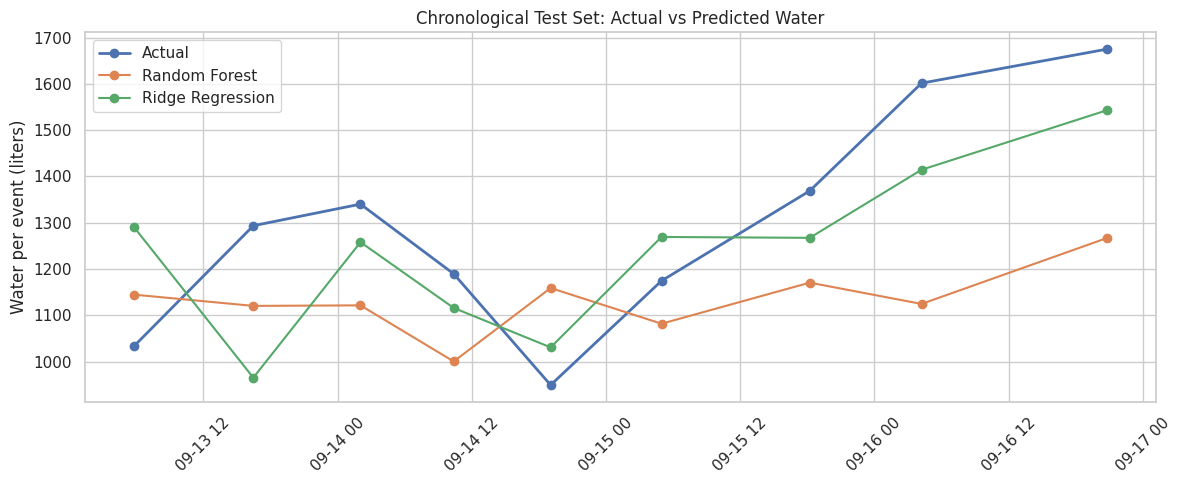

In [ ]:
# Header: Evaluate models using error metrics and compare with baseline
comparison = test[['start_time', TARGET]].reset_index(drop=True).copy()
comparison['Baseline_Predicted_L'] = baseline_prediction
for name, values in predictions.items():
    comparison[f'{name}_Predicted_L'] = values
display(comparison.round(2))

plt.figure(figsize=(12, 5))
plt.plot(comparison.start_time, comparison[TARGET], marker='o', linewidth=2, label='Actual')
for name in models:
    plt.plot(comparison.start_time, comparison[f'{name}_Predicted_L'], marker='o', label=name)
plt.ylabel('Water per event (liters)')
plt.title('Chronological Test Set: Actual vs Predicted Water')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Feature importance and example recommendation

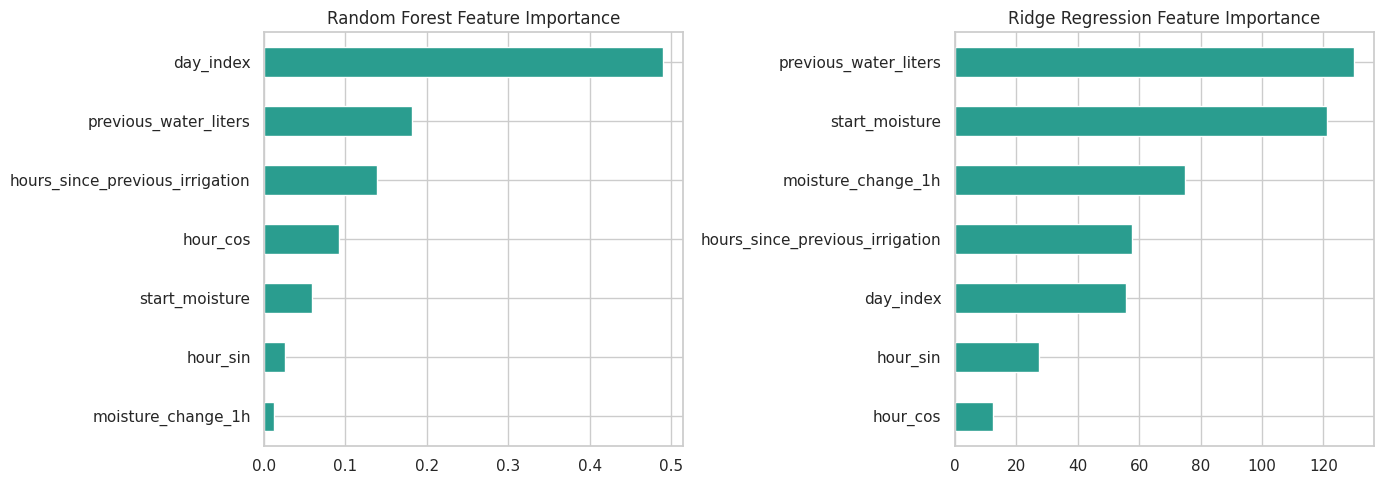

Selected model: Ridge Regression
Predicted applied water for a similar event: 1543.0 liters


In [ ]:
# Header: Create temporal features, soil moisture, and previous irrigation features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, model) in zip(axes, fitted_models.items()):
    if hasattr(model, 'feature_importances_'):
        values = model.feature_importances_
    else:
        values = np.abs(model.named_steps['ridge'].coef_)
    importance = pd.Series(values, index=FEATURES).sort_values()
    importance.plot.barh(ax=ax, color='#2a9d8f')
    ax.set_title(f'{name} Feature Importance')
plt.tight_layout()
plt.show()

# Select the better ML model by test MAE (baseline is excluded from deployment).
best_model_name = min(models, key=lambda n: mean_absolute_error(y_test, predictions[n]))
best_model = fitted_models[best_model_name]
latest_features = model_data[FEATURES].iloc[[-1]]
predicted_liters = float(np.clip(best_model.predict(latest_features)[0], 0, None))
print('Selected model:', best_model_name)
print(f'Predicted applied water for a similar event: {predicted_liters:.1f} liters')

## 9. Save outputs

The event table, test predictions, comparison metrics, and both trained models are saved. The feature list is saved with the selected model name so the same input order can be used later.

In [ ]:
# Header: Create temporal features, soil moisture, and previous irrigation features
events.to_csv('derived_irrigation_events.csv', index=False)
comparison.to_csv('water_volume_test_predictions.csv', index=False)
results_df.to_csv('water_volume_model_results.csv', index=False)

for name, model in fitted_models.items():
    joblib.dump(model, name.lower().replace(' ', '_') + '_water_model.joblib')

with open('water_model_metadata.json', 'w') as file:
    json.dump({
        'features': FEATURES,
        'target': TARGET,
        'best_model': best_model_name,
        'unit': 'liters_per_irrigation_event',
        'limitation': 'Applied water learned from one strawberry field; not universal optimal demand.'
    }, file, indent=2)

print('Output files created successfully.')

Output files created successfully.


In [ ]:
# Header: Train irrigation volume prediction models
# Download the main outputs. Uncomment model downloads if required.
files.download('water_volume_model_results.csv')
files.download('water_volume_test_predictions.csv')
# files.download('random_forest_water_model.joblib')
# files.download('ridge_regression_water_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>